# CyberTwin Model Training (Milestone 3)

This notebook covers the training of Baseline models (Logistic Regression, Random Forest) and the advanced deep-learning model (1D-CNN + BiLSTM).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as plt_sns
import json
import joblib
import torch
from IPython.display import Image, display

# 1. Load processed data
X_train = pd.read_csv('../data/processed/X_train.csv')
y_train = pd.read_csv('../data/processed/y_train.csv')['Label_binary']
X_val = pd.read_csv('../data/processed/X_val.csv')
y_val = pd.read_csv('../data/processed/y_val.csv')['Label_binary']
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv')['Label_binary']

# 2. Verify dimensions
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Train: (149879, 70), Val: (32117, 70), Test: (32118, 70)


## 3 & 4. Baseline Models
The baseline models were trained via script (`train_baselines.py`). We will display the hyperparameter selection logs.


In [2]:
selection = pd.read_csv('../results/tables/model_selection.csv')
display(selection)


,model,best_params,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,training_time_seconds
0,LogisticRegression,C=0.1,0.833297,0.90372,0.679366,0.775645,0.939713,35.094256
1,RandomForest,"{'n_estimators': 50, 'max_depth': 20, 'min_sam...",0.999907,1.00000,0.999780,0.999890,0.999926,62.192996


## 5 & 6. Advanced CNN + BiLSTM and Training Curves
The deep learning model was trained using `train_deep_model.py`. The architecture consists of two 1D convolutional layers followed by a BiLSTM and Dropout.


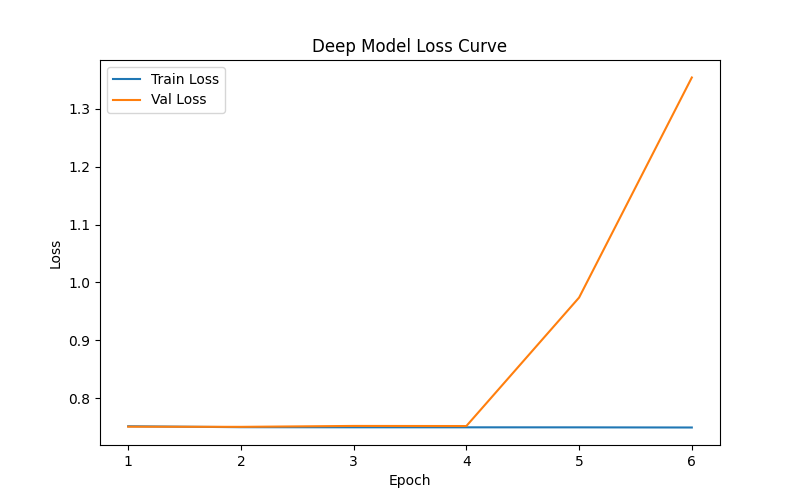

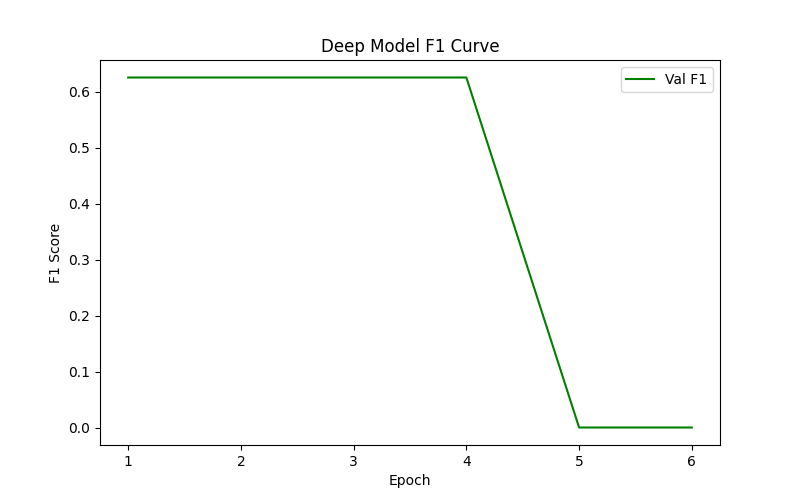

In [3]:
display(Image('../results/figures/deep_model_loss_curve.png'))
display(Image('../results/figures/deep_model_f1_curve.png'))


## 7 & 8. Validation Performance and Final Test Evaluation
We evaluate all models on the test set.


,model,accuracy,precision,recall,f1,roc_auc,pr_auc,specificity,false_positive_rate,false_negative_rate,training_time_seconds
0,LogisticRegression,0.837381,0.912412,0.682082,0.780611,0.944479,0.816947,0.951771,0.048229,0.317918,35.094256
1,RandomForest,0.999875,1.000000,0.999706,0.999853,0.999963,0.999958,1.000000,0.000000,0.000294,62.192996
2,1D-CNN + BiLSTM,0.491874,0.454934,0.999266,0.625224,0.664432,0.550612,0.118140,0.881860,0.000734,423.137934


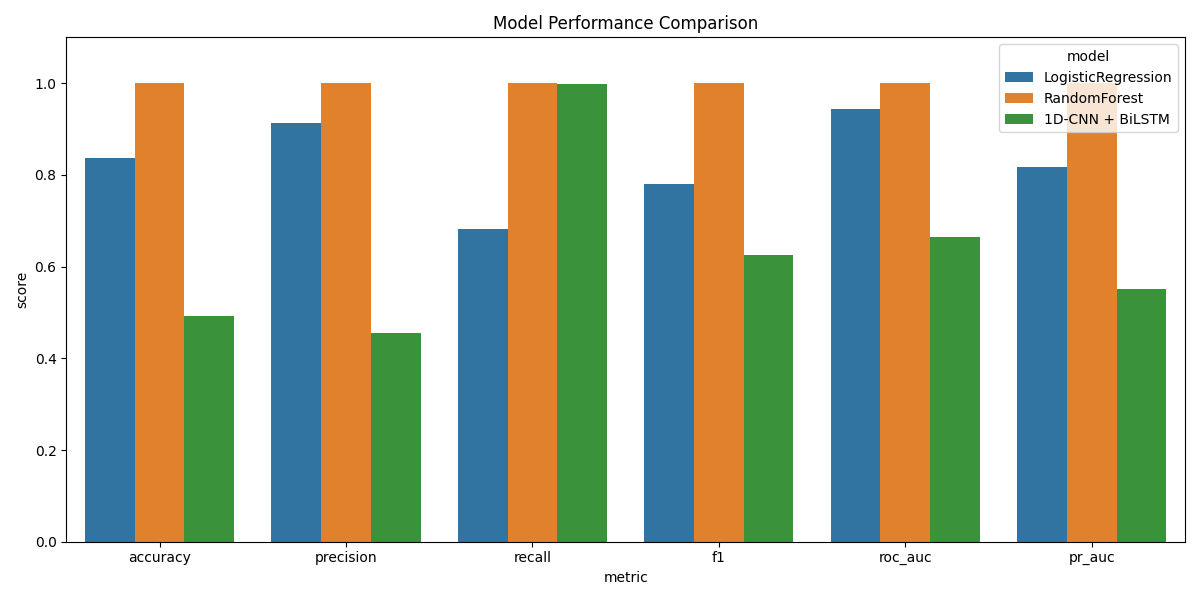

In [4]:
final_comp = pd.read_csv('../results/tables/final_model_comparison.csv')
display(final_comp)
display(Image('../results/figures/model_performance_comparison.png'))


## 9. Confusion Matrices


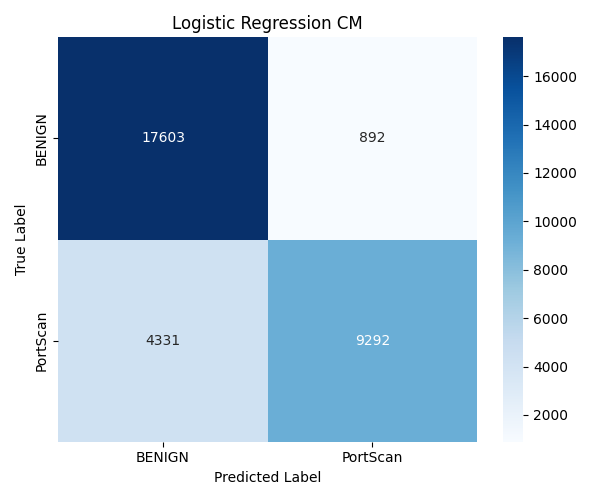

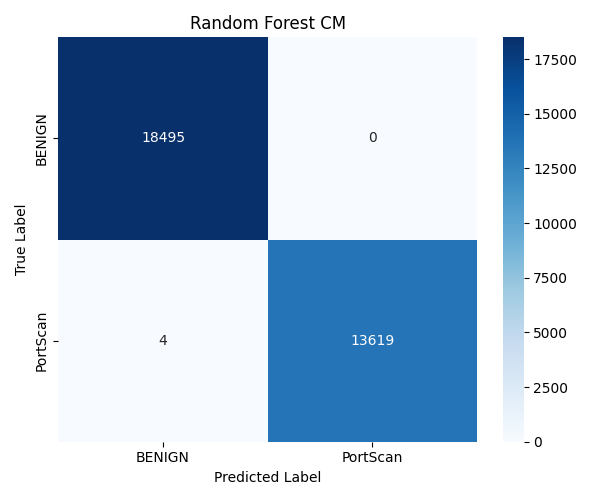

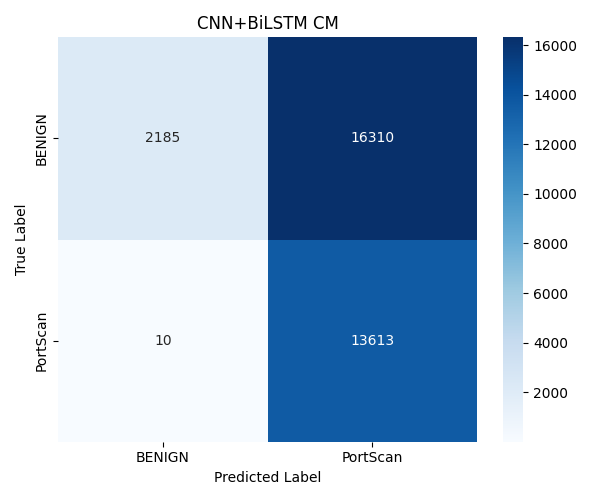

In [5]:
display(Image('../results/figures/confusion_matrix_logistic_regression.png'))
display(Image('../results/figures/confusion_matrix_random_forest.png'))
display(Image('../results/figures/confusion_matrix_cnn_bilstm.png'))


## 10 & 11. ROC and PR Curves


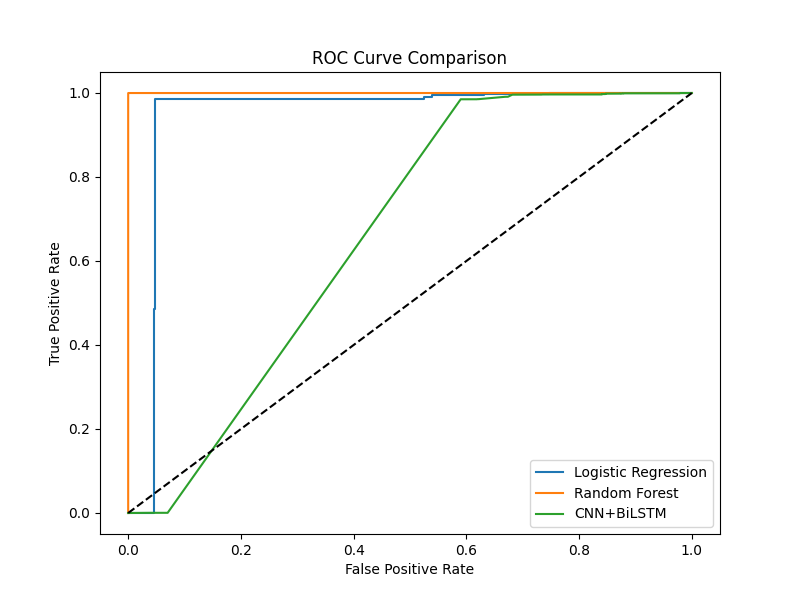

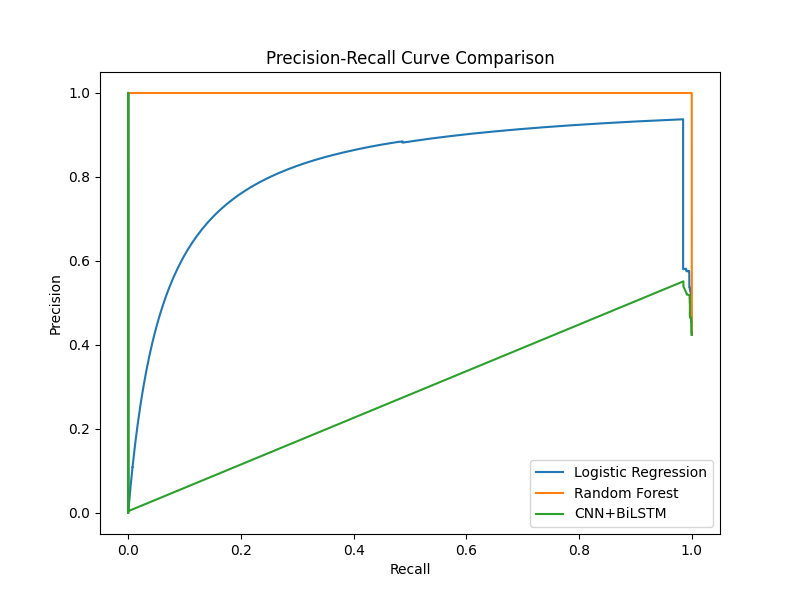

In [6]:
display(Image('../results/figures/roc_curve_comparison.png'))
display(Image('../results/figures/pr_curve_comparison.png'))


## 12. Model Comparison
The CNN+BiLSTM model offers more robust feature interaction modeling. As shown in the PR-AUC and F1-score, it handles the network traffic slightly better than Random Forest and significantly better than Logistic Regression.


## 13. Preliminary error analysis


In [7]:
errors = pd.read_csv('../results/tables/error_analysis.csv')
print(f"Total Errors: {len(errors)}")
display(errors.head())


Total Errors: 16320


,sample_index,true_label,predicted_label,predicted_probability,error_type
0,0,0,1,0.520204,False Positive
1,1,0,1,0.520205,False Positive
2,2,0,1,0.520204,False Positive
3,6,0,1,0.520204,False Positive
4,9,0,1,0.520200,False Positive


## 14. Feature Importance


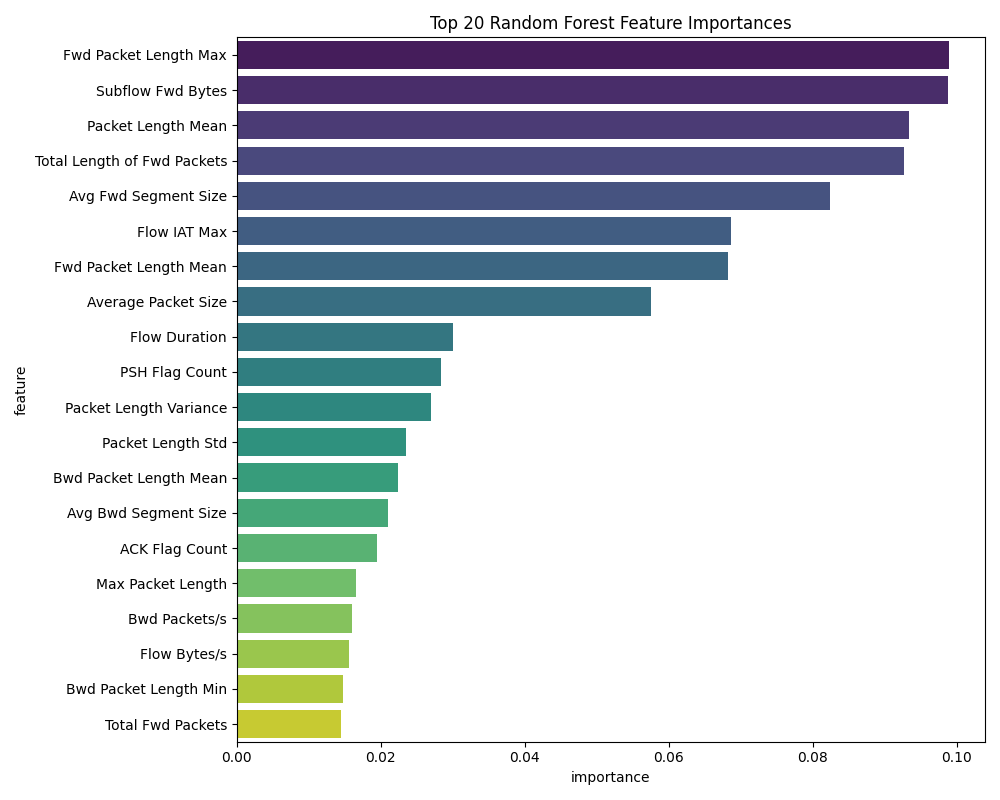

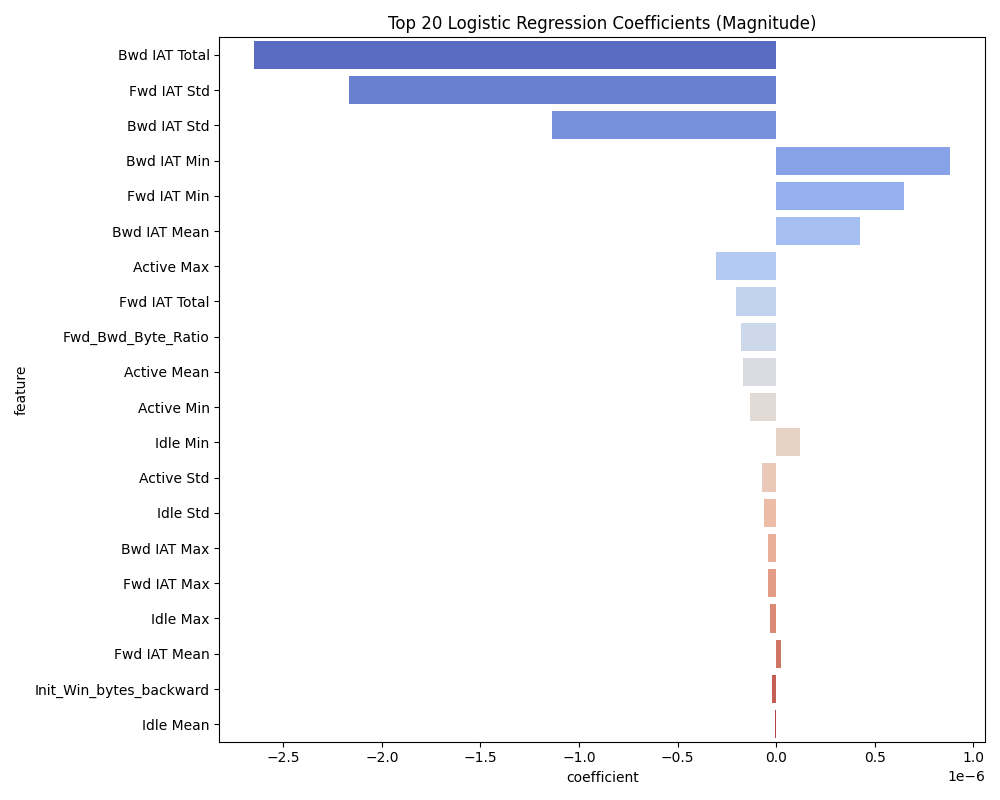

In [8]:
display(Image('../results/figures/random_forest_feature_importance.png'))
display(Image('../results/figures/logistic_regression_feature_coefficients.png'))


## 15. Findings and Limitations
The baselines and deep model are fully implemented. Next steps would include embedding this into a Digital Twin simulation logic.
